In [22]:
# Erstmal alle notwendigen Pakete importieren. Somit behält man auch die übersicht, wenn später noc welche hinzukommen.
import numpy as np
import matplotlib.pyplot as plt
import uncertainties 
import uncertainties.unumpy as unp
from uncertainties import ufloat
from scipy import optimize as opt

In [3]:
# Zuerst wollen wir die Daten einlesen. Dazu nutzen wir die Funktion loadtxt aus dem Paket numpy.
# Da wir mehrere Datenreihen haben, kann man sich hierfür eine Methode schreiben.
def load_data(filename):
    """
    Lädt die Daten aus einer Datei und gibt sie als numpy-Array zurück.
    """
    data = np.loadtxt(filename, delimiter=',', unpack=True, skiprows=1)
    return data
t, ax, ay, az, a = load_data("Default-Modul\Versuch-PYT\Messdaten Federpendel\Smartphone.csv")

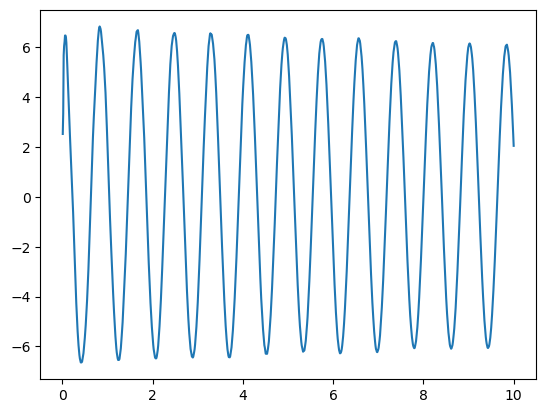

In [4]:
# Austetsten welche Beschleunigung benötigt wird.

#plt.plot(t, ax, label='ax')
plt.plot(t, ay, label='ay')
#plt.plot(t, az, label='az')
#plt.plot(t, a, label='a')

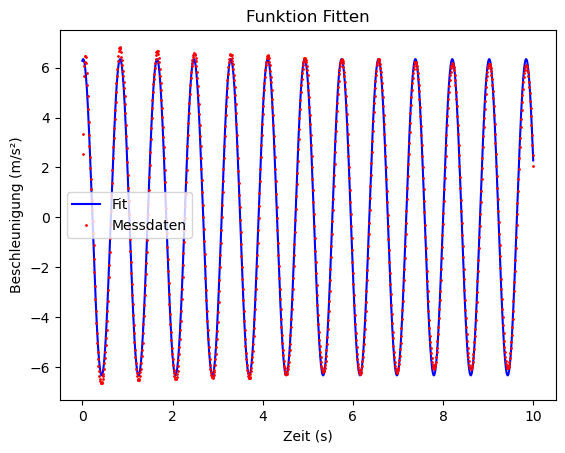

In [17]:
#Nun wird nach einer passenden Funktion gesucht, die die Daten beschreibt.
#Hierfür wird eine Funktion definiert. Offensichtlcher weise ist es eine Sinusfunktion, die die Beschleunigung in y-Richtung beschreibt.

def f(x, a, o, p):
    y = a*np.sin(o*x+p)
    return y

x = np.linspace(0, 10, 1000)  # Erstellen eines x-Werte Bereichs für die Funktion

para, cov = opt.curve_fit(f, t, ay, bounds=([5, 0, 0], [10, 15, np.pi])) # Berechnen der Parameter

y = f(x, *para)  # Berechnen der y-Werte für die Funktion

plt.plot(x, y, label='Fit', color='blue')  # Plotten der Funktion
plt.plot(t, ay, 'o', label='Messdaten', markersize='1', color='red')  # Plotten der Messdaten
plt.xlabel('Zeit (s)')
plt.ylabel('Beschleunigung (m/s²)')
plt.title('Funktion Fitten')
plt.legend()

Das sieht erstmal gut aus, am Anfang ist die gefittete Amplitude zu groß, am Ende zu klein. Das ist auch Richtig so, woran könnte dies liegen?
Wir erhalten nun also unsere Parameter:

In [ ]:
# Nun wir die Parameter zusammen mit ihren unsicherheiten Ausgeben ausgeben.
U = np.sqrt(np.diag(cov))  # Berechnen der Unsicherheiten
A = ufloat(para[0], U[0])  # Erstellen eines Unsicherheitsobjekts für die Amplitude
O = ufloat(para[1], U[1])  # Erstellen eines Unsicherheitsobjekts für die Frequenz
P = ufloat(para[2], U[2])  # Erstellen eines Unsicherheitsobjekts für die Phase
print(f"Amplitude: {A:.2f} m/s²")
print(f"Winkelfrequenz: {O:.2f} 1/s")
print(f"Phase: {P:.2f} rad")

Amplitude: 6.34+/-0.01 m/s²
Frequenz: 7.67+/-0.00 1/s
Phase: 1.42+/-0.00 rad


In [24]:
print(cov)

[[ 9.71981124e-05 -9.87800404e-09  2.26851272e-07]
 [-9.87800404e-09  2.96188657e-07 -1.47894659e-06]
 [ 2.26851272e-07 -1.47894659e-06  9.82659850e-06]]
